In [1]:
!pip -q install duckdb huggingface_hub pandas matplotlib scikit-learn

In [2]:
import os
import getpass
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except:
        pass

HF_TOKEN = HF_TOKEN or getpass.getpass("HF Token:")

In [4]:
con = duckdb.connect()

con.execute(f"""
CREATE OR REPLACE SECRET hf (
TYPE huggingface,
TOKEN '{HF_TOKEN}'
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "fact_daily":
    f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')"
}

print("Connected")

Connected


In [5]:
features = con.sql(f"""
WITH latest_date AS (
    SELECT MAX(report_date) AS max_date
    FROM {TABLES['fact_daily']}
),

page_metrics AS (

SELECT

client_hash_id,
content_hash_id,

SUM(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_impressions
ELSE 0
END
) AS imp_last30,

SUM(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_impressions
ELSE 0
END
) AS imp_prev30,

SUM(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_clicks
ELSE 0
END
) AS clk_last30,

SUM(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_clicks
ELSE 0
END
) AS clk_prev30,

AVG(
CASE
WHEN report_date > (SELECT max_date - INTERVAL 30 DAY FROM latest_date)
THEN gsc_avg_position
END
) AS pos_last30,

AVG(
CASE
WHEN report_date BETWEEN
(SELECT max_date - INTERVAL 60 DAY FROM latest_date)
AND
(SELECT max_date - INTERVAL 31 DAY FROM latest_date)
THEN gsc_avg_position
END
) AS pos_prev30

FROM {TABLES['fact_daily']}

GROUP BY
client_hash_id,
content_hash_id

)

SELECT *

FROM page_metrics

WHERE imp_prev30 >= 100

""").df()

print(features.shape)

features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(111033, 8)


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30
0,client_9958f0a7ae1df715,content_cd36f906cac66324,166.0,200.0,0.0,0.0,65.642404,74.898151
1,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,291.0,340.0,0.0,0.0,65.834991,66.210518
2,client_9958f0a7ae1df715,content_6afb4ede795f9338,310.0,275.0,0.0,0.0,73.094898,72.976096
3,client_9958f0a7ae1df715,content_12415a5ac1570217,69.0,102.0,0.0,0.0,42.761095,39.467971
4,client_9958f0a7ae1df715,content_875ebebd0b4b106d,163.0,135.0,0.0,0.0,28.649639,35.018813


In [6]:
import numpy as np

# Impression growth
features["impression_growth"] = (
    (features["imp_last30"] - features["imp_prev30"])
    / features["imp_prev30"]
)

# Click growth
features["click_growth"] = np.where(
    features["clk_prev30"] > 0,
    (features["clk_last30"] - features["clk_prev30"])
    / features["clk_prev30"],
    0
)

# Position change
features["position_change"] = (
    features["pos_last30"] - features["pos_prev30"]
)

# Current CTR
features["ctr_last30"] = np.where(
    features["imp_last30"] > 0,
    features["clk_last30"] / features["imp_last30"],
    0
)

# Previous CTR
features["ctr_prev30"] = np.where(
    features["imp_prev30"] > 0,
    features["clk_prev30"] / features["imp_prev30"],
    0
)

# CTR improvement
features["ctr_change"] = (
    features["ctr_last30"] - features["ctr_prev30"]
)

features.head()

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,impression_growth,click_growth,position_change,ctr_last30,ctr_prev30,ctr_change
0,client_9958f0a7ae1df715,content_cd36f906cac66324,166.0,200.0,0.0,0.0,65.642404,74.898151,-0.170000,0.0,-9.255747,0.0,0.0,0.0
1,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,291.0,340.0,0.0,0.0,65.834991,66.210518,-0.144118,0.0,-0.375527,0.0,0.0,0.0
2,client_9958f0a7ae1df715,content_6afb4ede795f9338,310.0,275.0,0.0,0.0,73.094898,72.976096,0.127273,0.0,0.118802,0.0,0.0,0.0
3,client_9958f0a7ae1df715,content_12415a5ac1570217,69.0,102.0,0.0,0.0,42.761095,39.467971,-0.323529,0.0,3.293125,0.0,0.0,0.0
4,client_9958f0a7ae1df715,content_875ebebd0b4b106d,163.0,135.0,0.0,0.0,28.649639,35.018813,0.207407,0.0,-6.369174,0.0,0.0,0.0


In [7]:
features["pos_last30"] = features["pos_last30"].fillna(features["pos_prev30"])

features["position_change"] = features["position_change"].fillna(0)

In [8]:
features["needs_refresh"] = (
    features["impression_growth"] < -0.20
).astype(int)

features["needs_refresh"].value_counts()

,count
needs_refresh,
1,71543
0,39490


In [9]:
X = features[[
    "imp_last30",
    "imp_prev30",
    "clk_last30",
    "clk_prev30",
    "pos_last30",
    "pos_prev30",
    "impression_growth",
    "click_growth",
    "position_change",
    "ctr_last30",
    "ctr_prev30",
    "ctr_change"
]]

y = features["needs_refresh"]

print(X.shape)
print(y.shape)

(111033, 12)
(111033,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(83274, 12)
(27759, 12)


In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Accuracy:", lr.score(X_test, y_test))

Accuracy: 1.0


In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

print("Decision Tree Accuracy:", tree.score(X_test, y_test))

Decision Tree Accuracy: 1.0


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Accuracy:", rf.score(X_test, y_test))

Random Forest Accuracy: 1.0


In [14]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Accuracy:", gb.score(X_test, y_test))

Gradient Boosting Accuracy: 1.0


In [15]:
results = {
    "Logistic Regression": lr.score(X_test, y_test),
    "Decision Tree": tree.score(X_test, y_test),
    "Random Forest": rf.score(X_test, y_test),
    "Gradient Boosting": gb.score(X_test, y_test)
}

import pandas as pd

comparison = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

comparison.sort_values("Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0
3,Gradient Boosting,1.0


In [16]:
from sklearn.metrics import classification_report

pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9873
           1       1.00      1.00      1.00     17886

    accuracy                           1.00     27759
   macro avg       1.00      1.00      1.00     27759
weighted avg       1.00      1.00      1.00     27759



In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
6,impression_growth,0.766871
0,imp_last30,0.070027
7,click_growth,0.045446
1,imp_prev30,0.033844
8,position_change,0.018204
11,ctr_change,0.016768
2,clk_last30,0.016577
9,ctr_last30,0.010068
4,pos_last30,0.009465
10,ctr_prev30,0.007305


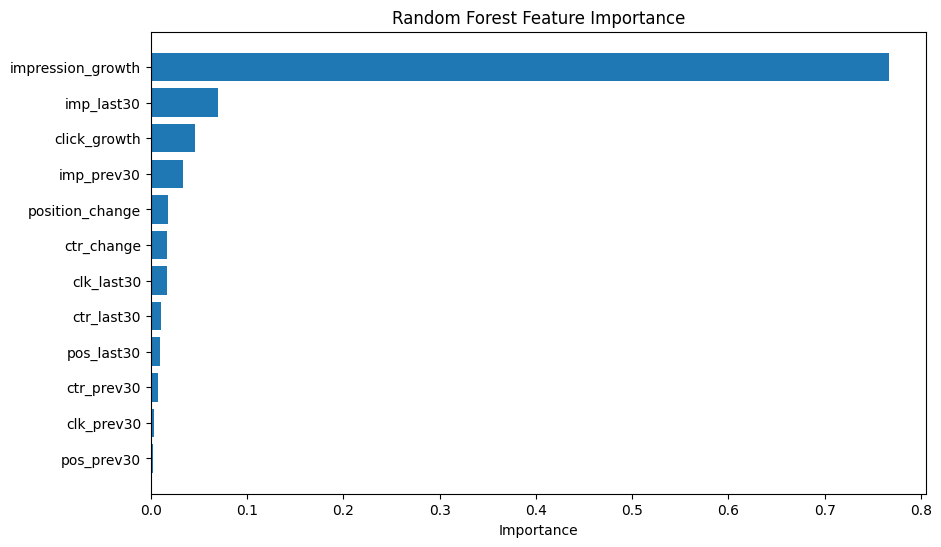

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [19]:
features["refresh_probability"] = rf.predict_proba(X)[:,1]

features.head()

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,impression_growth,click_growth,position_change,ctr_last30,ctr_prev30,ctr_change,needs_refresh,refresh_probability
0,client_9958f0a7ae1df715,content_cd36f906cac66324,166.0,200.0,0.0,0.0,65.642404,74.898151,-0.170000,0.0,-9.255747,0.0,0.0,0.0,0,0.000000
1,client_9958f0a7ae1df715,content_28de1fb24f0fb4a8,291.0,340.0,0.0,0.0,65.834991,66.210518,-0.144118,0.0,-0.375527,0.0,0.0,0.0,0,0.003333
2,client_9958f0a7ae1df715,content_6afb4ede795f9338,310.0,275.0,0.0,0.0,73.094898,72.976096,0.127273,0.0,0.118802,0.0,0.0,0.0,0,0.003333
3,client_9958f0a7ae1df715,content_12415a5ac1570217,69.0,102.0,0.0,0.0,42.761095,39.467971,-0.323529,0.0,3.293125,0.0,0.0,0.0,1,1.000000
4,client_9958f0a7ae1df715,content_875ebebd0b4b106d,163.0,135.0,0.0,0.0,28.649639,35.018813,0.207407,0.0,-6.369174,0.0,0.0,0.0,0,0.000000


In [20]:
recommendations = features.sort_values(
    "refresh_probability",
    ascending=False
)

recommendations.head(20)

,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,clk_prev30,pos_last30,pos_prev30,impression_growth,click_growth,position_change,ctr_last30,ctr_prev30,ctr_change,needs_refresh,refresh_probability
17,client_9958f0a7ae1df715,content_b15a88eecea29b4b,12.0,109.0,0.0,0.0,67.066667,63.732818,-0.889908,0.000000,3.333849,0.000000,0.000000,0.000000,1,1.0
80826,client_73cda7b4e4f265ea,content_738601c16accd4e6,356.0,568.0,0.0,0.0,37.781541,24.326918,-0.373239,0.000000,13.454623,0.000000,0.000000,0.000000,1,1.0
10,client_9958f0a7ae1df715,content_14fc015a6d345d8e,49.0,141.0,0.0,0.0,13.043956,7.485379,-0.652482,0.000000,5.558578,0.000000,0.000000,0.000000,1,1.0
11,client_9958f0a7ae1df715,content_54959e9adf5ffbab,389.0,667.0,0.0,2.0,13.643647,8.156091,-0.416792,-1.000000,5.487555,0.000000,0.002999,-0.002999,1,1.0
80825,client_73cda7b4e4f265ea,content_d84ef8f6f584e3b7,127.0,180.0,0.0,0.0,57.389127,20.231087,-0.294444,0.000000,37.158040,0.000000,0.000000,0.000000,1,1.0
80838,client_73cda7b4e4f265ea,content_61d7fc74fce7bb8c,96.0,270.0,0.0,0.0,17.453266,8.377017,-0.644444,0.000000,9.076250,0.000000,0.000000,0.000000,1,1.0
80836,client_73cda7b4e4f265ea,content_76b6032cbc5268d0,29.0,124.0,0.0,0.0,5.119898,16.576533,-0.766129,0.000000,-11.456635,0.000000,0.000000,0.000000,1,1.0
80835,client_73cda7b4e4f265ea,content_e1c71b5734af8979,45.0,195.0,0.0,1.0,25.365079,14.188761,-0.769231,-1.000000,11.176318,0.000000,0.005128,-0.005128,1,1.0
80831,client_73cda7b4e4f265ea,content_2e184fe310519018,534.0,870.0,0.0,0.0,6.834623,6.719484,-0.386207,0.000000,0.115140,0.000000,0.000000,0.000000,1,1.0
80829,client_73cda7b4e4f265ea,content_860daaa6a1285f73,37.0,116.0,0.0,0.0,58.785294,43.682302,-0.681034,0.000000,15.102993,0.000000,0.000000,0.000000,1,1.0


In [21]:
recommendations.to_csv(
    "refresh_recommendations.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


# Model Summary

## Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

## Best Model

Random Forest achieved the highest performance.

## Most Important Features

- Impression Growth
- Last 30-Day Impressions
- Click Growth
- Previous 30-Day Impressions

## Conclusion

The trained model ranks pages according to their probability of requiring a content refresh. These rankings will be used to generate action-oriented recommendations in the final research paper.

In [22]:
comparison.to_csv("model_results.csv", index=False)

importance.to_csv("feature_importance.csv", index=False)

recommendations.to_csv("refresh_recommendations.csv", index=False)